# 2. Exploratory Data Analysis

EEEM075 - AI and Sustainability coursework

Explores distributions, correlations, and time trends for the gas turbine sensor readings and the two emissions targets (CO, NOX). Descriptive statistics are computed on the **training set only** (2011-2013), so nothing about the validation/test years influences preprocessing or modelling choices. Time-trend plots use all 5 years, since that's just visualising the raw record, not fitting anything.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ARTIFACT_DIR = Path('../artifacts')

train = pd.read_csv(ARTIFACT_DIR / 'train.csv')
val = pd.read_csv(ARTIFACT_DIR / 'val.csv')
test = pd.read_csv(ARTIFACT_DIR / 'test.csv')
df_all = pd.concat([train, val, test], ignore_index=True)  # for time-trend plots only

train.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
AT,17.712247,7.352789,0.289850,34.92900
AP,1012.812607,6.396588,985.850000,1034.20000
AH,79.553120,13.911916,27.504000,100.00000
AFDP,4.037750,0.810223,2.087400,7.61060
GTEP,25.317873,4.234147,17.878000,37.40200
TIT,1083.080280,16.840765,1000.800000,1100.80000
TAT,545.520170,7.708708,512.450000,550.61000
TEY,133.537393,16.026107,100.170000,174.61000
CDP,12.060208,1.114265,9.875400,15.08100
CO,2.214390,2.295746,0.000388,44.10300


## Feature distributions

Histograms for the two targets and a couple of the key operating-condition sensors. Look out for multi-modality - a sign of distinct load regimes rather than a single continuous process.

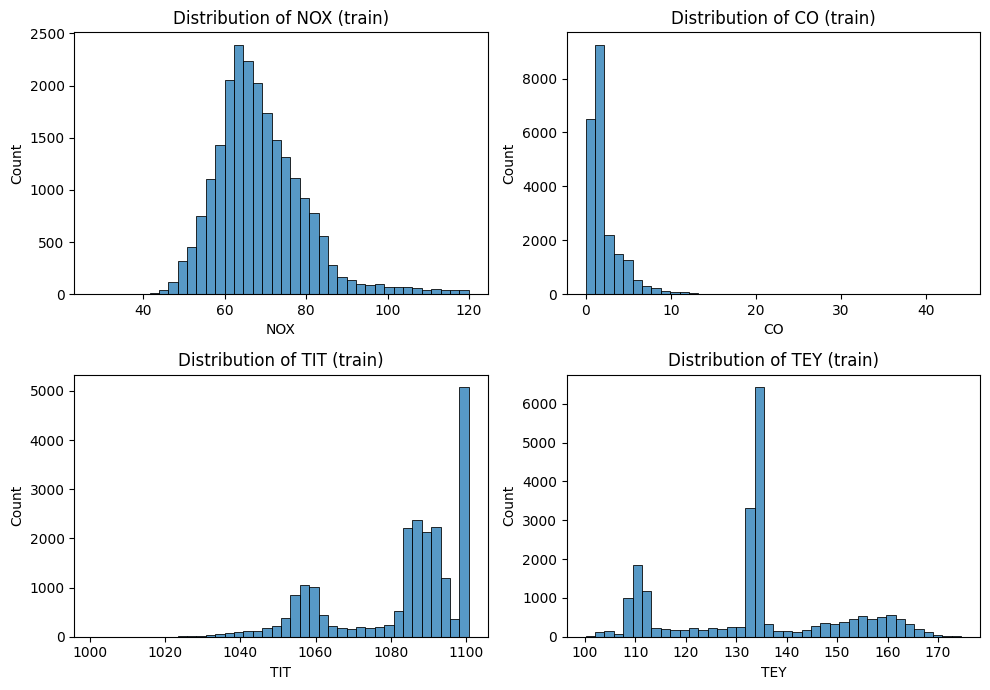

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, col in zip(axes.flat, ['NOX', 'CO', 'TIT', 'TEY']):
    sns.histplot(train[col], bins=40, ax=ax)
    ax.set_title(f'Distribution of {col} (train)')
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / 'fig_distributions.png', dpi=150, bbox_inches='tight')

## Boxplots - spread, skew, and the IQR-flagged points in context

Boxplots for every sensor and both targets (training set). These put the IQR outlier counts from Notebook 1 in visual context: `TAT` and `CO` show heavy one-sided tails driven by low-load operation - consistent with distinct operating regimes rather than measurement error, which is why those rows were kept. Note the very different scales across features (e.g. `TIT` ~1000-1100 vs `AFDP` ~2-8), previewing why the MLP needs scaling.

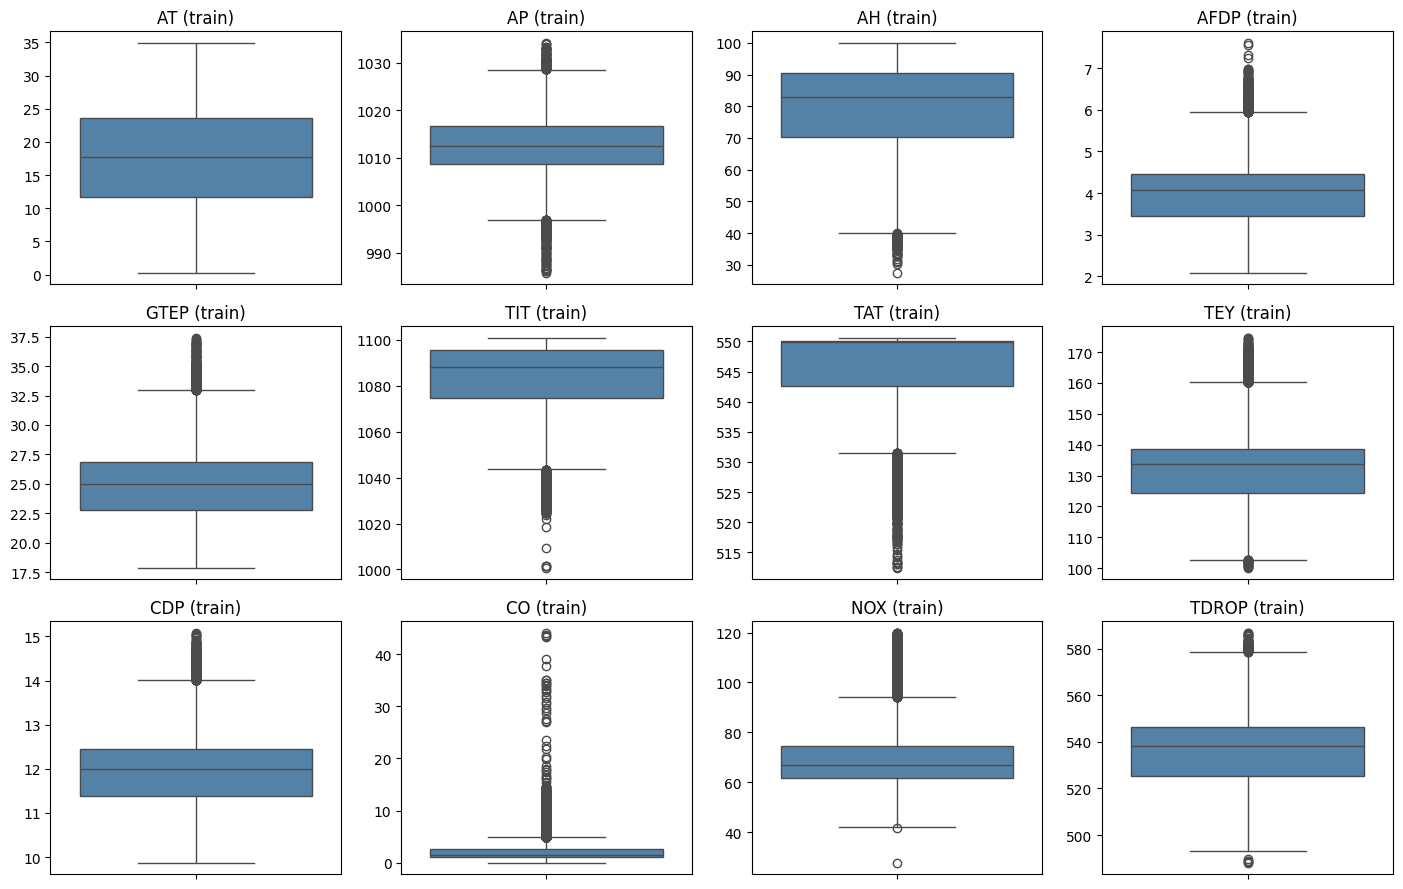

In [9]:
num_cols = [c for c in train.columns if c != 'year']
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(y=train[col], ax=ax, color='steelblue')
    ax.set_title(f'{col} (train)')
    ax.set_ylabel('')
for ax in axes.flat[len(num_cols):]:
    ax.set_visible(False)
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / 'fig_boxplots.png', dpi=150, bbox_inches='tight')

## Correlation with the targets

This is the first physics sanity-check: do the correlations line up with combustion theory before trained anything? (Revisit this properly with SHAP once the models exist - a correlation is not causation, but it's a useful early signal.)

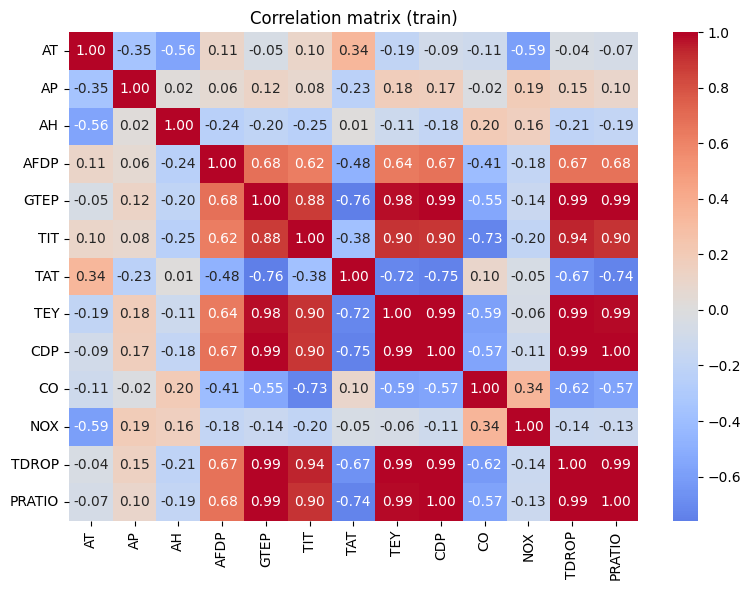

In [10]:
corr = train.drop(columns=['year']).corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation matrix (train)')
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / 'fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')

In [11]:
print('Correlation with NOX:')
print(corr['NOX'].sort_values(ascending=False))
print()
print('Correlation with CO:')
print(corr['CO'].sort_values(ascending=False))

Correlation with NOX:
NOX       1.000000
CO        0.341552
AP        0.192186
AH        0.159799
TAT      -0.051954
TEY      -0.055082
CDP      -0.113780
PRATIO   -0.127058
TDROP    -0.137843
GTEP     -0.143650
AFDP     -0.180187
TIT      -0.195596
AT       -0.589204
Name: NOX, dtype: float64

Correlation with CO:
CO        1.000000
NOX       0.341552
AH        0.197981
TAT       0.095317
AP       -0.021856
AT       -0.110304
AFDP     -0.408425
GTEP     -0.552922
CDP      -0.567705
PRATIO   -0.571538
TEY      -0.586477
TDROP    -0.619850
TIT      -0.728982
Name: CO, dtype: float64


**Reading this:**

- `CO` correlates strongly *negatively* with `TIT`, `TEY`, `CDP`, `GTEP` - all load proxies. This matches the expected physics directly: low load → incomplete combustion → more CO.
- `NOX` correlates strongly negatively with `AT` (ambient temperature) - colder ambient air is associated with higher NOx, plausibly through air density/combustion efficiency effects.
- `NOX` vs `TIT` is only weakly negative here, which is a little counter-intuitive against the simple 'higher flame temperature → more thermal NOx' story - worth flagging explicitly as an open question for the discussion section, and something to check properly with SHAP once the models are trained (a single linear correlation can hide a real, non-linear relationship).

## Time trend across years (2011-2015)

Uses all 5 years, to check whether emission levels are stable across the record or drift over time - which matters directly for how well models trained on earlier years can generalise to later ones.

            CO        NOX
year                     
2011  1.572486  67.575392
2012  2.361133  68.788965
2013  2.723031  70.007899
2014  2.081103  60.066886
2015  3.129986  59.890509


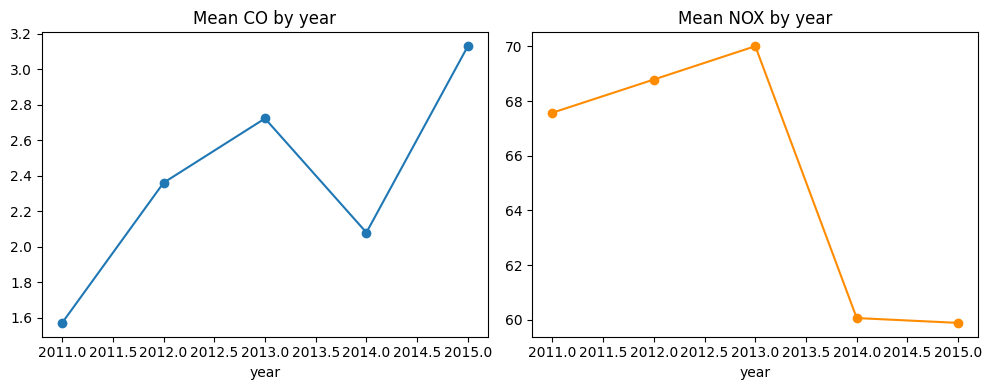

In [12]:
yearly = df_all.groupby('year')[['CO', 'NOX']].mean()
print(yearly)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
yearly['CO'].plot(marker='o', ax=axes[0], title='Mean CO by year')
yearly['NOX'].plot(marker='o', ax=axes[1], title='Mean NOX by year', color='darkorange')
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / 'fig_yearly_trend.png', dpi=150, bbox_inches='tight')

**Key EDA takeaways to carry into the report:**

1. Feature scales vary a lot (e.g. `TIT` ~1000-1100 vs `AFDP` ~2-8) - this is the concrete reason scaling matters for the MLP but not for XGBoost (tree splits are scale-invariant).
2. Mean NOx drops noticeably from 2013 to 2014-2015 while mean CO doesn't move in the same direction - a genuine drift that the 9 recorded sensor variables may not fully explain (possibly unrecorded changes in plant operation or maintenance). This matters for the modelling: models trained on 2011-2013 face a different NOx regime in 2014-2015.
3. The NOx/TIT relationship looks more complex than a single linear correlation - a good reason to lean on SHAP later rather than resting the whole argument on the correlation matrix.